In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = os.path.dirname(os.getcwd()) + '/PDAC/sim/TNBC_outputs/'

In [5]:
keys = ['c','t','tcd4','mdsc','mac','fib']
counts = {}
for i in range(len(keys)):
    counts[keys[i]] = np.zeros(1601)

for i in range(1601):
    temp = pd.read_csv(path + 'snapShots/cell_core_0_' + str(i) + '.csv',header=0)
    ag_type = temp['Type'].to_numpy()
    for j in range(len(keys)):
        counts[keys[j]][i] = len(ag_type[ag_type==(j+1)])
    
    

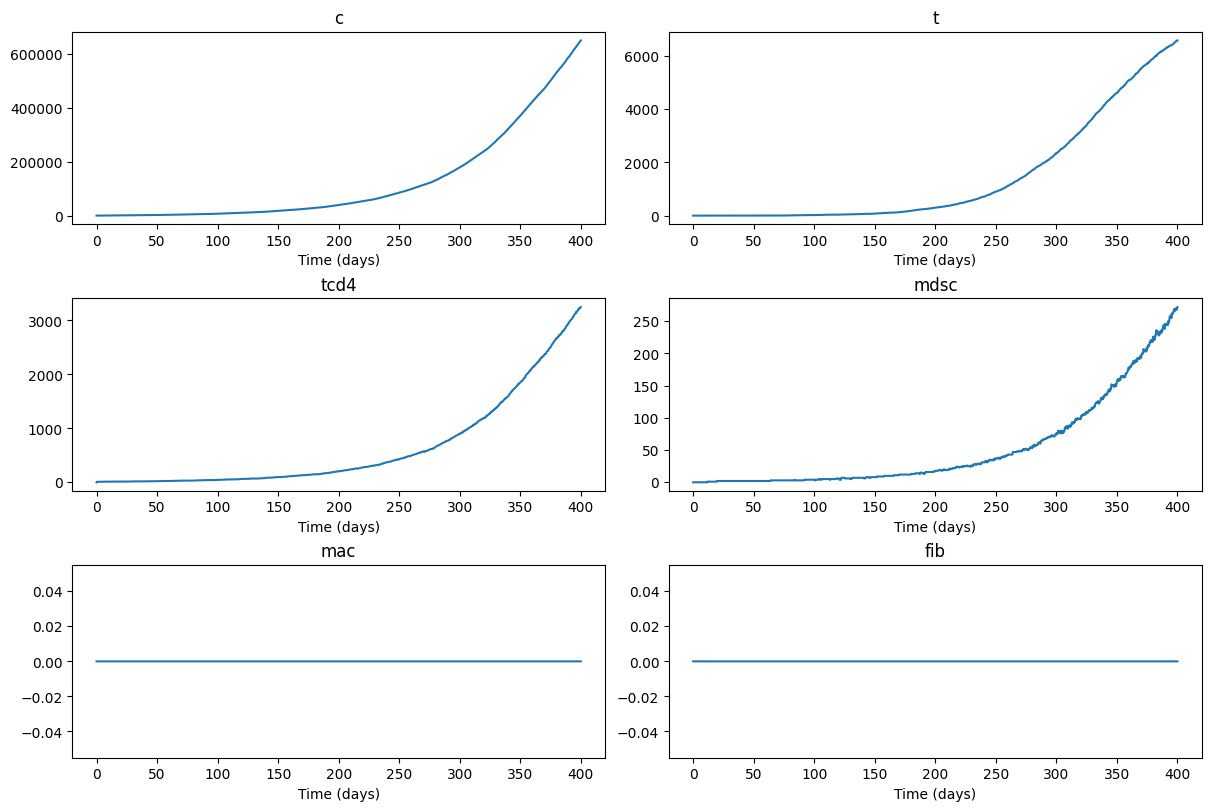

In [6]:
fig,axes = plt.subplots(3,2,figsize=(12,8),layout = 'constrained')
t = np.linspace(0,400,1601)
for i,ax in enumerate(axes.reshape(-1)):
    ax.plot(t, counts[keys[i]], label = keys[i])
    ax.set_title(keys[i])
    ax.set_xlabel('Time (days)')

In [8]:
temp = pd.read_csv(path + 'QSP_0.csv',header=0)
columns = ['V_T.C1','V_T.T1','V_T.T0','V_T.MDSC']
qsp_counts = {}
for elem in keys:
    qsp_counts[elem] = np.zeros(1601)

for i, elem in enumerate(columns):
    data = temp[elem].to_numpy()
    qsp_counts[keys[i]] = data[:]

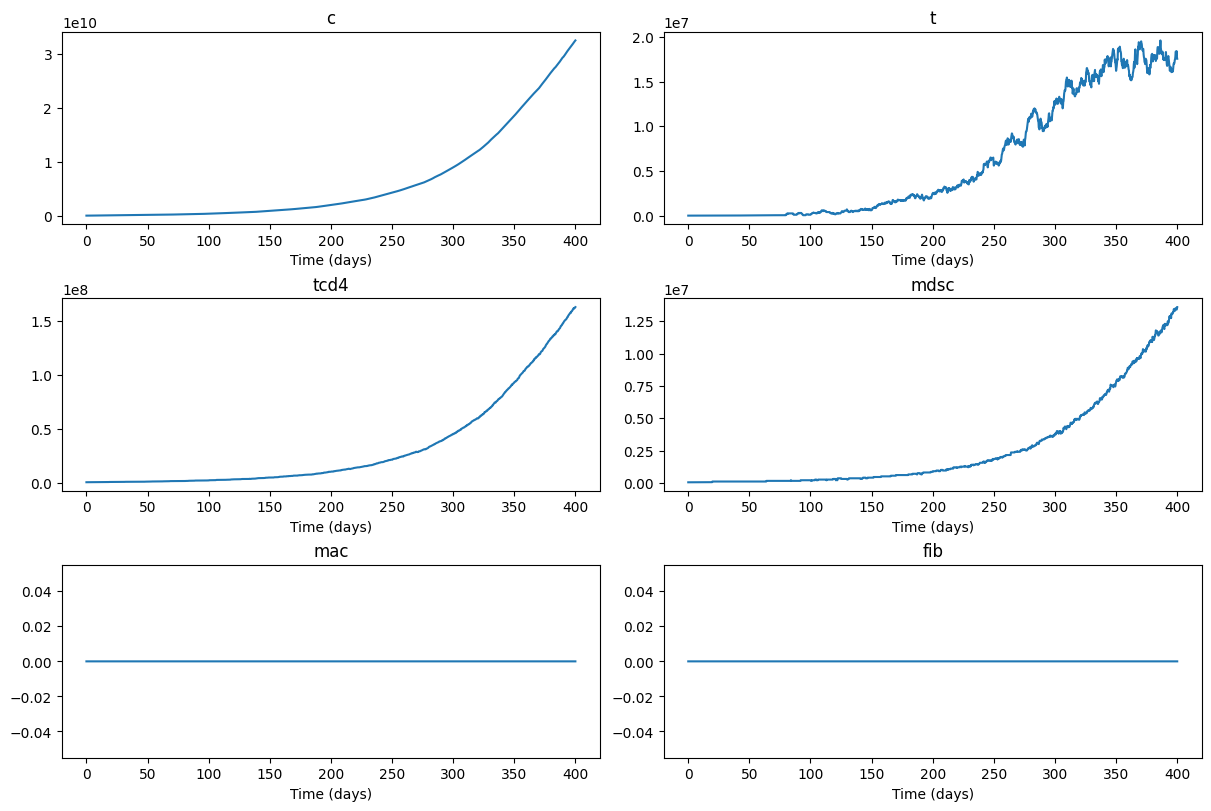

In [11]:
fig,axes = plt.subplots(3,2,figsize=(12,8),layout = 'constrained')
t = np.linspace(0,400,1601)
for i,ax in enumerate(axes.reshape(-1)):
    ax.plot(t, qsp_counts[keys[i]], label = keys[i])
    ax.set_title(keys[i])
    ax.set_xlabel('Time (days)')